# Grid Network Analysis - Week 3, Task 3.2: Advanced Visualizations and Insights

**Scope**: Part A Task 3.2 only. Network graphs and the interactive
geographic map are already covered in `02_network_analysis.ipynb` and
`03_geographic_analysis.ipynb` - this notebook adds the remaining
visualization types the spec calls out: a chord-style inter-region flow
diagram, line-density and maintenance heatmaps, an animated
commissioning-year map, and a utility comparison chart.

All logic lives in `../src/viz.py` (unit tested in `../tests/test_viz.py`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from src.cleaning import load_raw, clean_and_validate, merge_all
from src.viz import (
    build_chord_diagram, build_line_density_heatmap, build_maintenance_heatmap,
    build_animated_commissioning_map, build_utility_comparison_chart,
)

DATA_DIR = Path("../data")
CHARTS_DIR = Path("../outputs/charts")
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

utilities, substations, lines = load_raw(DATA_DIR)
utilities, substations, lines, _ = clean_and_validate(utilities, substations, lines)
merged = merge_all(utilities, substations, lines)

## Chord diagram: inter-regional line flow

Each arc connects two regions that share at least one line; arc thickness
is proportional to how many lines connect them - a quick visual answer to
"which regions are most interconnected?"

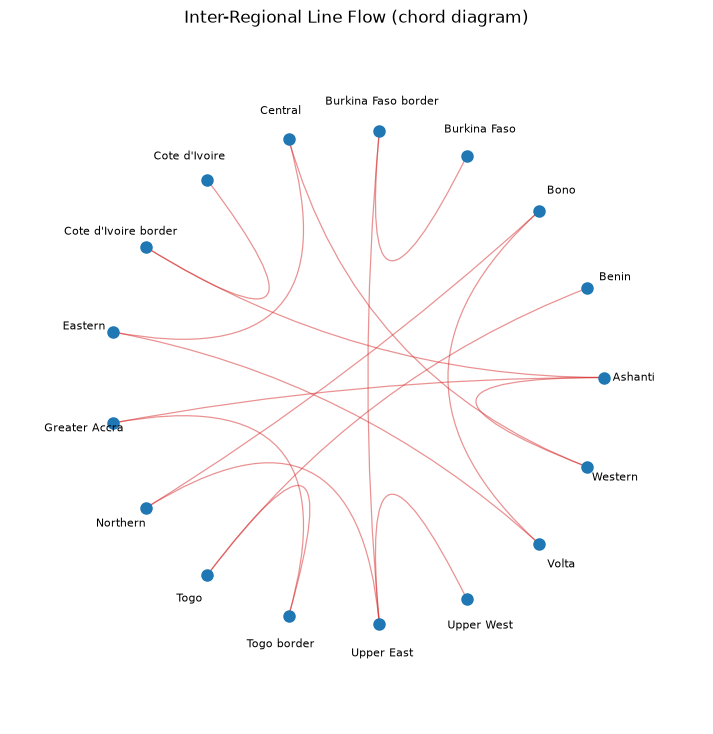

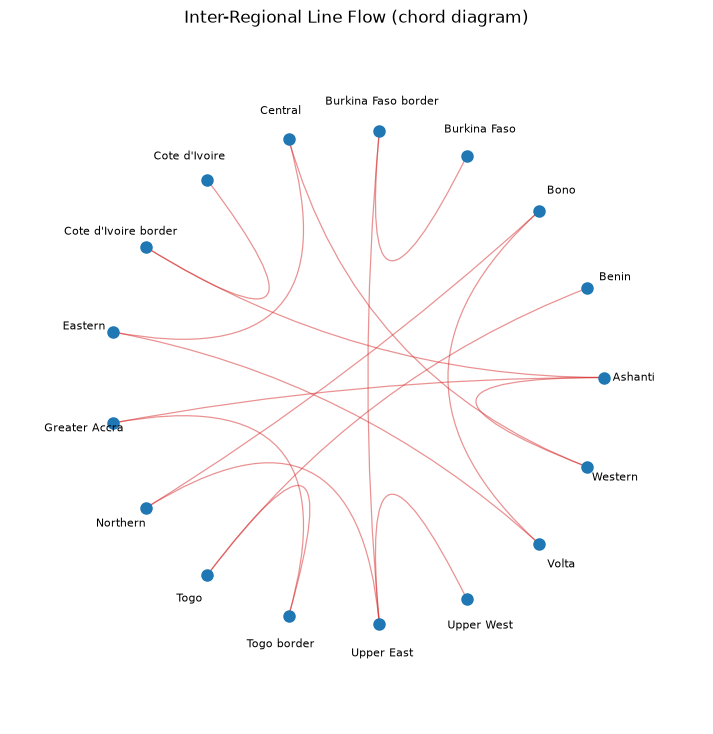

In [2]:
fig = build_chord_diagram(merged)
fig.savefig(CHARTS_DIR / "chord_diagram.png", dpi=150, bbox_inches="tight")
fig

## Heatmap: line density by region and voltage tier

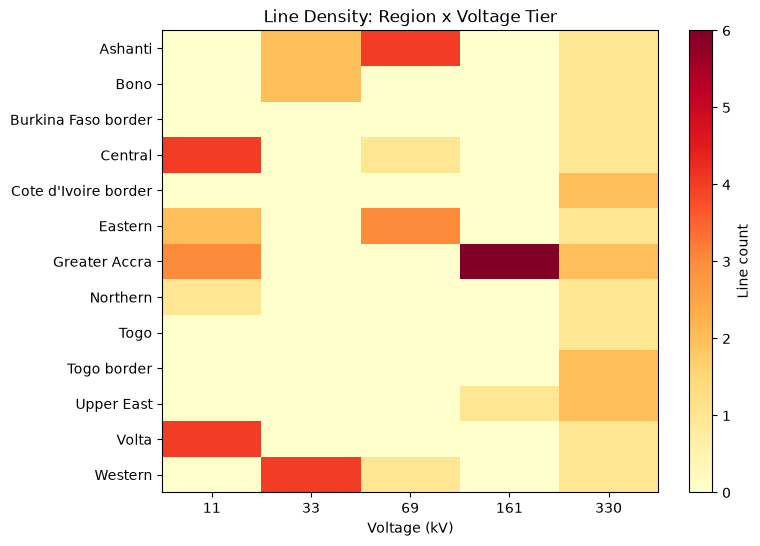

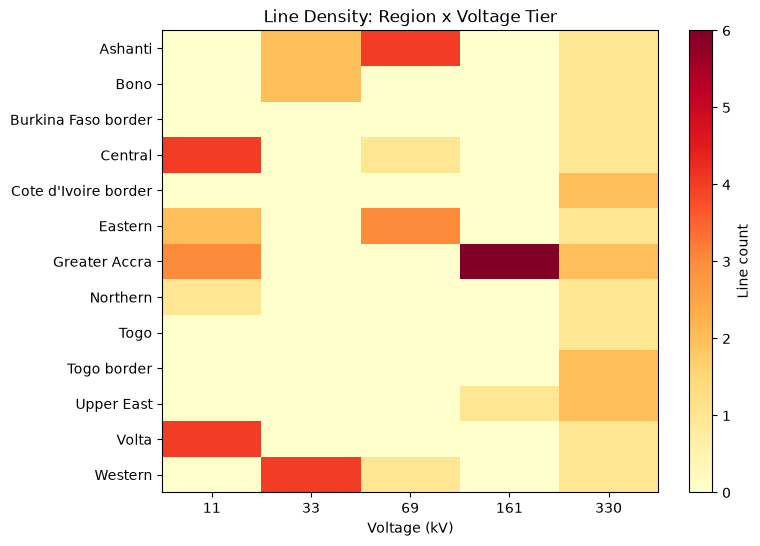

In [3]:
fig = build_line_density_heatmap(merged)
fig.savefig(CHARTS_DIR / "line_density_heatmap.png", dpi=150, bbox_inches="tight")
fig

## Heatmap: maintenance-status intensity by region and utility

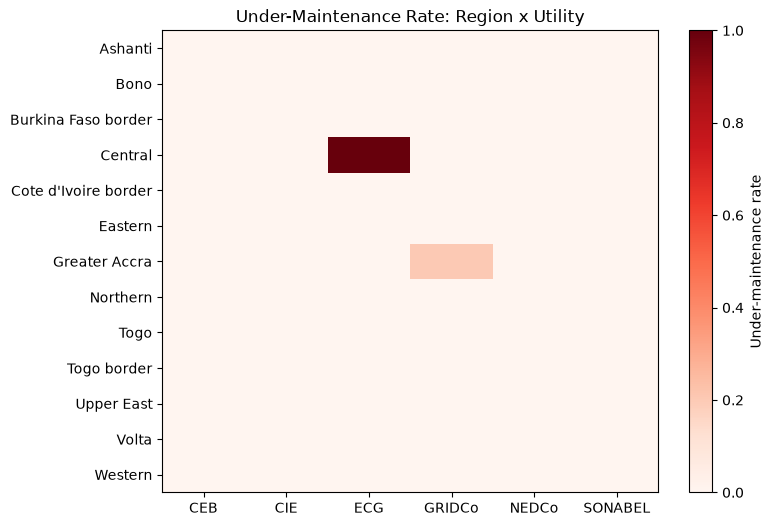

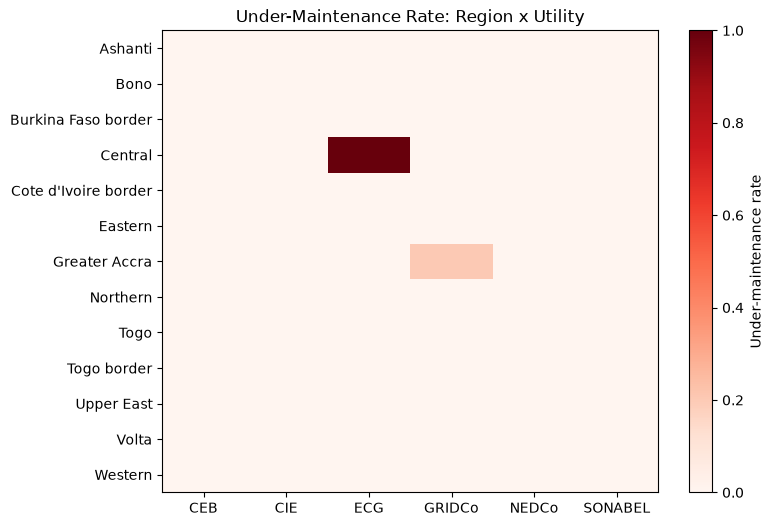

In [4]:
fig = build_maintenance_heatmap(merged)
fig.savefig(CHARTS_DIR / "maintenance_heatmap.png", dpi=150, bbox_inches="tight")
fig

## Animated map: grid growth by commissioning decade

Play through the animation frames to see the network grow decade by
decade (cumulative - each frame includes every substation commissioned in
or before that decade).

In [5]:
anim_fig = build_animated_commissioning_map(substations)
anim_fig.write_html(str(Path("../outputs") / "commissioning_growth_map.html"))
anim_fig.show()

## Comparative chart: utility line count vs total capacity

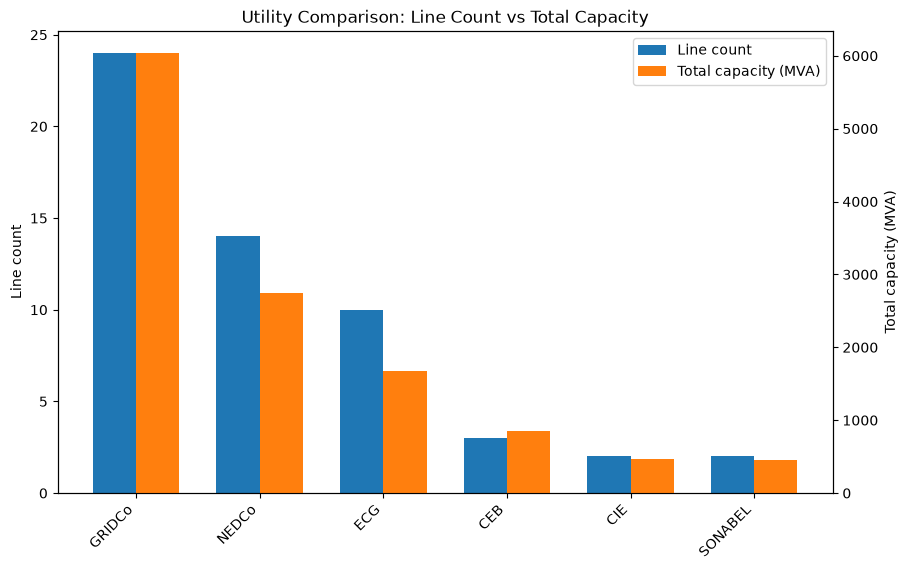

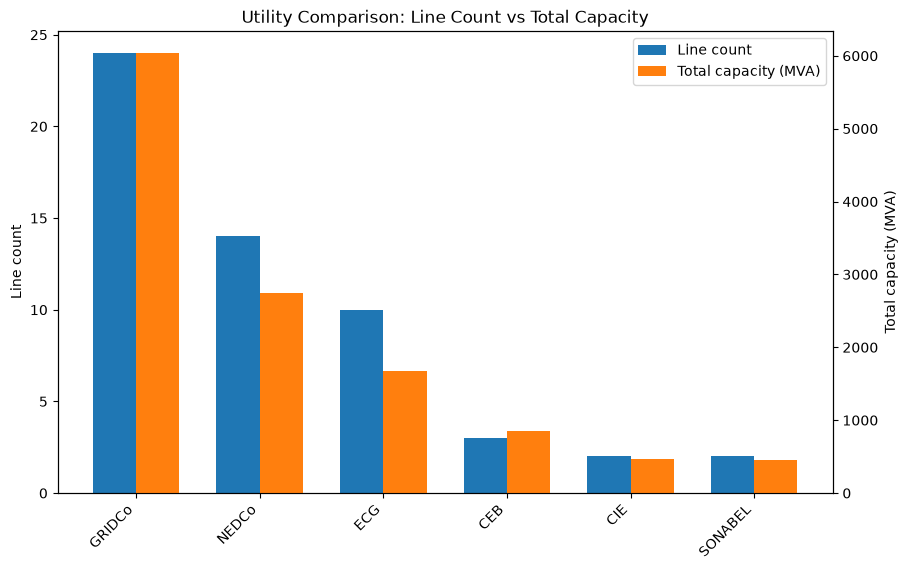

In [6]:
fig = build_utility_comparison_chart(merged)
fig.savefig(CHARTS_DIR / "utility_comparison.png", dpi=150, bbox_inches="tight")
fig

## Design documentation and style guide (Task 3.2 deliverable)

- **Color choice**: heatmaps use sequential colormaps (`YlOrRd`, `Reds`)
  since the underlying values (line count, maintenance rate) are ordered
  with a meaningful zero, not diverging or categorical.
- **Chord diagram**: kept intentionally simple (no third-party chord
  library) - arcs are quadratic Bezier curves through the circle's center,
  width scaled linearly by line count. Self-loops (source region ==
  destination region) are excluded since they don't represent
  inter-regional flow.
- **Animated map**: uses cumulative frames (each decade includes all prior
  decades) rather than decade-only snapshots, since "grid growth" implies
  accumulation, not replacement.
- All charts reuse the same voltage-tier color convention established in
  `03_geographic_analysis.ipynb`'s Folium map, for visual consistency
  across the whole analysis.

## Notes and limitations

Derived from the same synthetic, seeded dataset used throughout - see
`../../docs/architecture-diagrams/grid-analysis-data-dictionary.md`.